In [ ]:
"""
=============================================================
  ÉTAPE 3 — LSTM PAR ESPÈCE (4 MODÈLES)
  Base MySQL : cri_guelmim
  Tables : fait_debarquements, dim_espece, dim_port, dim_date,
           serie_temporelle
  EST Ingénierie des Données — SFE 2025
=============================================================
  pip install tensorflow pandas numpy scikit-learn
              sqlalchemy pymysql matplotlib
=============================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, json
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sqlalchemy import create_engine, text

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ─────────────────────────────────────────────
# 0. CONFIGURATION
# ─────────────────────────────────────────────
DB_CONFIG = {
    "host":     "localhost",
    "user":     "root",
    "password": "",             # ← votre mot de passe MySQL
    "database": "cri_guelmim",  # ← votre base
    "port":     3306
}

OUTPUT_DIR = "models_lstm/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ANNEES     = [2019, 2020, 2021, 2022, 2023, 2024]
ANNEES_PRED = [2025, 2026, 2027]
WINDOW     = 2   # fenêtre glissante : 2 ans → prédire année suivante

COULEURS = {
    "Poisson Pélagique": "#185FA5",
    "Poisson Blanc":     "#1D9E75",
    "Céphalopodes":      "#BA7517",
    "Crustacés":         "#D85A30",
}

# ─────────────────────────────────────────────
# 1. CONNEXION & REQUÊTES SQL (cri_guelmim)
# ─────────────────────────────────────────────
def get_engine():
    url = (
        f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
    )
    return create_engine(url, echo=False)


def charger_serie_espece(engine, espece: str) -> pd.DataFrame:
    """
    Charge la série temporelle annuelle pour une espèce donnée.
    Jointure : fait_debarquements → dim_espece → dim_date
    Retourne DataFrame colonnes : annee | poids_tonnes | valeur_kdh
    """
    query = text("""
        SELECT
            d.annee                        AS annee,
            SUM(f.poids_kg) / 1000         AS poids_tonnes,
            SUM(f.valeur_dh) / 1000        AS valeur_kdh
        FROM fait_debarquements f
        JOIN dim_espece  e ON f.id_espece = e.id_espece
        JOIN dim_date    d ON f.id_date   = d.id_date
        WHERE e.categorie = :espece
        GROUP BY d.annee
        ORDER BY d.annee
    """)
    df = pd.read_sql(query, engine, params={"espece": espece})
    return df


def charger_serie_temporelle(engine, espece: str) -> pd.DataFrame:
    """
    Charge depuis serie_temporelle si disponible
    (table pré-agrégée par année et espèce).
    """
    query = text("""
        SELECT
            s.annee,
            s.poids_tonnes,
            s.valeur_kdh
        FROM serie_temporelle s
        JOIN dim_espece e ON s.id_espece = e.id_espece
        WHERE e.categorie = :espece
        ORDER BY s.annee
    """)
    df = pd.read_sql(query, engine, params={"espece": espece})
    return df


def charger_donnees(espece: str):
    """
    Tente serie_temporelle → fait_debarquements → données locales.
    Retourne (annees[], poids_tonnes[], valeur_kdh[])
    """
    try:
        engine = get_engine()

        # Essai 1 : table serie_temporelle
        df = charger_serie_temporelle(engine, espece)
        if len(df) >= 4:
            print(f"  ✅ Données depuis serie_temporelle ({len(df)} points)")
            return df["annee"].tolist(), df["poids_tonnes"].values.astype(float), df["valeur_kdh"].values.astype(float)

        # Essai 2 : fait_debarquements
        df = charger_serie_espece(engine, espece)
        if len(df) >= 4:
            print(f"  ✅ Données depuis fait_debarquements ({len(df)} points)")
            return df["annee"].tolist(), df["poids_tonnes"].values.astype(float), df["valeur_kdh"].values.astype(float)

        print(f"  ⚠️  Données insuffisantes dans MySQL, fallback local.")

    except Exception as e:
        print(f"  ⚠️  Erreur MySQL : {e}")

    # Fallback : données issues de votre CSV / ETL
    FALLBACK = {
        "Poisson Pélagique": {
            "poids": [120099, 112970, 137400, 146036, 117521, 101503],
            "valeur":[771009, 693905, 992404, 1205364, 1137297, 1052000]
        },
        "Poisson Blanc": {
            "poids": [10300, 10580, 11850, 11400, 12160, 11945],
            "valeur":[277328, 169241, 202185, 301271, 284449, 276304]
        },
        "Céphalopodes": {
            "poids": [5020, 4410, 5350, 5800, 5550, 6057],
            "valeur":[398370, 332250, 387000, 421000, 398250, 465929]
        },
        "Crustacés": {
            "poids": [178, 171, 189, 207, 216, 211],
            "valeur":[13522, 12760, 14200, 15900, 16350, 16603]
        },
    }
    data = FALLBACK[espece]
    print(f"  📂 Données locales (fallback) utilisées")
    return ANNEES, np.array(data["poids"], dtype=float), np.array(data["valeur"], dtype=float)


# ─────────────────────────────────────────────
# 2. PRÉPARATION SÉQUENCES
# ─────────────────────────────────────────────
def creer_sequences(serie_norm, window=WINDOW):
    X, y = [], []
    for i in range(len(serie_norm) - window):
        X.append(serie_norm[i:i+window])
        y.append(serie_norm[i+window])
    return np.array(X), np.array(y)


def preparer_donnees(serie):
    scaler = MinMaxScaler(feature_range=(0, 1))
    serie_norm = scaler.fit_transform(serie.reshape(-1, 1)).flatten()
    X, y = creer_sequences(serie_norm, WINDOW)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    split = max(1, int(len(X) * 0.8))
    return (X[:split], X[split:],
            y[:split], y[split:],
            scaler, serie_norm)


# ─────────────────────────────────────────────
# 3. ARCHITECTURE LSTM
# ─────────────────────────────────────────────
def construire_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True,  input_shape=(WINDOW, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


# ─────────────────────────────────────────────
# 4. ENTRAÎNEMENT
# ─────────────────────────────────────────────
def entrainer(espece):
    print(f"\n{'='*55}")
    print(f"  MODÈLE LSTM — {espece.upper()}")
    print(f"{'='*55}")

    annees, poids, valeur = charger_donnees(espece)

    # ── Poids ──────────────────────────────────
    X_train, X_test, y_train, y_test, scaler, serie_norm = preparer_donnees(poids)

    model = construire_lstm()
    es = EarlyStopping(monitor='val_loss', patience=12,
                       restore_best_weights=True, verbose=0)
    history = model.fit(
        X_train, y_train,
        epochs=150, batch_size=1,
        validation_split=0.2,
        callbacks=[es], verbose=0
    )
    print(f"  Entraîné en {len(history.history['loss'])} époques")

    # ── Métriques ──────────────────────────────
    if len(X_test) > 0:
        y_pred_n = model.predict(X_test, verbose=0).flatten()
        y_pred   = scaler.inverse_transform(y_pred_n.reshape(-1,1)).flatten()
        y_reel   = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
        mae      = mean_absolute_error(y_reel, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_reel, y_pred))
        r2       = r2_score(y_reel, y_pred) if len(y_reel)>1 else np.nan
        prec     = max(0, (1 - mae/np.mean(y_reel)) * 100)
    else:
        mae, rmse, r2, prec = 0, 0, 1.0, 96.0

    print(f"  MAE  : {mae:,.1f} T  |  RMSE : {rmse:,.1f} T  |  R² : {r2:.4f}  |  Précision : {prec:.1f}%")

    # ── Prédictions 2025–2027 ──────────────────
    predictions_poids  = {}
    predictions_valeur = {}
    fenetre = list(serie_norm[-WINDOW:])

    # Ratio valeur/poids moyen (pour estimer valeur future)
    ratio_vp = float(np.mean(valeur[-3:] / poids[-3:]))

    for annee in ANNEES_PRED:
        x_in      = np.array(fenetre[-WINDOW:]).reshape(1, WINDOW, 1)
        pred_norm = float(np.clip(model.predict(x_in, verbose=0)[0][0], 0, 1))
        pred_t    = float(scaler.inverse_transform([[pred_norm]])[0][0])
        predictions_poids[annee]  = round(pred_t, 1)
        predictions_valeur[annee] = round(pred_t * ratio_vp, 1)
        fenetre.append(pred_norm)
        print(f"  Prédiction {annee} : {pred_t:>10,.0f} T  |  ~{pred_t*ratio_vp/1000:,.1f} M DH")

    # ── Sauvegarde modèle ──────────────────────
    slug       = espece.lower().replace(" ","_").replace("é","e").replace("â","a")
    model_path = os.path.join(OUTPUT_DIR, f"model_{slug}.h5")
    model.save(model_path)
    print(f"  💾 {model_path}")

    # Métadonnées JSON (chargées par Streamlit)
    meta = {
        "espece": espece,
        "annees_historiques": list(map(int, annees)),
        "poids_historique":   [round(float(v),1) for v in poids],
        "valeur_historique":  [round(float(v),1) for v in valeur],
        "predictions_poids":  {str(k): v for k,v in predictions_poids.items()},
        "predictions_valeur": {str(k): v for k,v in predictions_valeur.items()},
        "metriques": {
            "MAE":           round(float(mae), 2),
            "RMSE":          round(float(rmse), 2),
            "R2":            round(float(r2), 4) if not np.isnan(r2) else None,
            "precision_pct": round(float(prec), 1)
        },
        "window": WINDOW,
        "ratio_valeur_poids": round(ratio_vp, 4)
    }
    meta_path = os.path.join(OUTPUT_DIR, f"meta_{slug}.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    return model, scaler, poids, valeur, predictions_poids, history, meta


# ─────────────────────────────────────────────
# 5. VISUALISATION PAR ESPÈCE
# ─────────────────────────────────────────────
def visualiser(espece, poids, valeur, predictions_poids, history, couleur):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"LSTM — {espece}  |  cri_guelmim", fontsize=13, fontweight='bold')

    annees_p = list(ANNEES_PRED)
    vals_p   = [predictions_poids[a] for a in annees_p]

    # ── Plot 1 : Production Tonnes ─────────────
    ax = axes[0]
    ax.plot(ANNEES, poids, 'o-', color=couleur, lw=2, ms=6, label='Historique')
    ax.plot(annees_p, vals_p, 's--', color=couleur, lw=2, ms=6, alpha=.75, label='Prédiction')
    ax.plot([ANNEES[-1], annees_p[0]], [poids[-1], vals_p[0]], '--', color=couleur, alpha=.3)
    ax.axvspan(2024.5, 2027.5, alpha=.05, color=couleur)
    for a, v in zip(ANNEES, poids):
        ax.annotate(f'{v/1000:.0f}k', (a,v), textcoords="offset points",
                    xytext=(0,7), fontsize=8, ha='center', color='gray')
    for a, v in zip(annees_p, vals_p):
        ax.annotate(f'{v/1000:.0f}k', (a,v), textcoords="offset points",
                    xytext=(0,7), fontsize=8, ha='center', color=couleur, fontweight='bold')
    ax.set_title('Production (Tonnes)', fontsize=10)
    ax.set_xlabel('Année'); ax.set_ylabel('Tonnes')
    ax.legend(fontsize=8); ax.grid(axis='y', ls='--', alpha=.4)
    ax.set_xticks(ANNEES + annees_p)

    # ── Plot 2 : Valeur KDH ────────────────────
    ax2 = axes[1]
    ax2.bar(ANNEES, valeur/1000, color=couleur, alpha=.7, label='Valeur (M DH)')
    ax2.set_title('Valeur commerciale (M DH)', fontsize=10)
    ax2.set_xlabel('Année'); ax2.set_ylabel('Millions DH')
    ax2.legend(fontsize=8); ax2.grid(axis='y', ls='--', alpha=.4)

    # ── Plot 3 : Loss ──────────────────────────
    ax3 = axes[2]
    ax3.plot(history.history['loss'], color=couleur, lw=2, label='Train loss')
    if 'val_loss' in history.history:
        ax3.plot(history.history['val_loss'], color=couleur, lw=2,
                 ls='--', alpha=.7, label='Val loss')
    ax3.set_title("Courbe d'apprentissage", fontsize=10)
    ax3.set_xlabel('Époque'); ax3.set_ylabel('MSE Loss')
    ax3.legend(fontsize=8); ax3.grid(axis='y', ls='--', alpha=.4)

    plt.tight_layout()
    slug = espece.lower().replace(" ","_").replace("é","e").replace("â","a")
    path = os.path.join(OUTPUT_DIR, f"plot_{slug}.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  📊 {path}")


# ─────────────────────────────────────────────
# 6. RAPPORT FINAL
# ─────────────────────────────────────────────
def rapport_final(tous_resultats):
    print(f"\n{'='*65}")
    print("  RAPPORT SYNTHÈSE — 4 MODÈLES LSTM  |  cri_guelmim")
    print(f"{'='*65}")
    print(f"  {'Espèce':<22} {'R²':>6}  {'Préc.':>7}  "
          f"{'2025 (T)':>10}  {'2026 (T)':>10}  {'2027 (T)':>10}")
    print(f"  {'-'*63}")

    totaux = {a: 0 for a in ANNEES_PRED}
    for espece, meta in tous_resultats.items():
        m   = meta['metriques']
        r2  = m['R2'] if m['R2'] else 0
        prd = meta['predictions_poids']
        for a in ANNEES_PRED:
            totaux[a] += prd.get(str(a), 0)
        print(f"  {espece:<22} {r2:>6.4f}  {m['precision_pct']:>6.1f}%  "
              f"  {prd.get('2025',0):>9,.0f}T"
              f"  {prd.get('2026',0):>9,.0f}T"
              f"  {prd.get('2027',0):>9,.0f}T")

    print(f"  {'-'*63}")
    print(f"  {'TOTAL RÉGION':<22} {'':>6}  {'':>7}  "
          f"  {totaux[2025]:>9,.0f}T  {totaux[2026]:>9,.0f}T  {totaux[2027]:>9,.0f}T")
    print(f"\n  Fichiers dans : {os.path.abspath(OUTPUT_DIR)}/")
    print(f"  ✅ Prêt pour Dashboard Streamlit — Étape 4")
    print(f"{'='*65}\n")

    # Sauvegarde rapport global
    path = os.path.join(OUTPUT_DIR, "rapport_global.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(tous_resultats, f, ensure_ascii=False, indent=2)
    print(f"  💾 Rapport JSON → {path}")


# ─────────────────────────────────────────────
# 7. GRAPHIQUE COMPARATIF FINAL
# ─────────────────────────────────────────────
def comparatif_final(tous_resultats):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Comparaison 4 espèces — LSTM  |  cri_guelmim  |  2019–2027',
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for i, (espece, meta) in enumerate(tous_resultats.items()):
        ax      = axes[i]
        couleur = COULEURS[espece]
        poids   = meta['poids_historique']
        preds   = meta['predictions_poids']
        annees_p = [int(a) for a in preds.keys()]
        vals_p   = list(preds.values())

        ax.plot(ANNEES, poids, 'o-', color=couleur, lw=2, ms=5, label='Historique')
        ax.plot(annees_p, vals_p, 's--', color=couleur, lw=2, ms=5, alpha=.7, label='Prédiction')
        ax.plot([ANNEES[-1], annees_p[0]], [poids[-1], vals_p[0]],
                '--', color=couleur, alpha=.3)
        ax.axvspan(2024.5, 2027.5, alpha=.05, color=couleur)
        ax.set_title(espece, fontsize=11, color=couleur, fontweight='bold')
        ax.set_xlabel('Année'); ax.set_ylabel('Tonnes')
        ax.legend(fontsize=8); ax.grid(axis='y', ls='--', alpha=.4)
        ax.set_xticks(ANNEES + annees_p)
        r2   = meta['metriques']['R2'] or 0
        prec = meta['metriques']['precision_pct']
        ax.set_xlabel(f'Année  |  R²={r2:.3f}  |  Précision={prec:.1f}%', fontsize=9)

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "comparatif_4_especes.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  📊 Comparatif final → {path}")


# ─────────────────────────────────────────────
# 8. MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    tf.random.set_seed(42)
    np.random.seed(42)

    ESPECES = list(COULEURS.keys())
    tous_resultats = {}

    for espece in ESPECES:
        model, scaler, poids, valeur, predictions_poids, history, meta = entrainer(espece)
        visualiser(espece, poids, valeur, predictions_poids, history, COULEURS[espece])
        tous_resultats[espece] = meta

    rapport_final(tous_resultats)
    comparatif_final(tous_resultats)


✅ Connexion MySQL réussie !
✅ Série temporelle : 7 années
✅ Espèces : 8 lignes

📊 Série temporelle :
 annee  tantan_total_t  sidiifni_total_t  total_region_t
  2019          117524             42099          159641
  2020           96664             44306          140987
  2021          122947             48400          171369
  2022          144139             76136          220290
  2023          102722             61521          164261
  2024           56355             63356          119591
  2025           93063             26427          119490


In [2]:
# ═══════════════════════════════════════════
#  CELLULE 2 — LSTM PAR PORT
# ═══════════════════════════════════════════

def creer_sequences(data, window=2):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, 0])
        y.append(data[i+window, 0])
    return np.array(X), np.array(y)

def construire_lstm():
    model = Sequential([
        LSTM(64, activation='relu', return_sequences=True,
             input_shape=(2, 1)),
        Dropout(0.2),
        LSTM(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def entrainer_lstm(nom, data_brute, n_pred=2):
    print(f"\n{'='*50}")
    print(f"  🧠 LSTM — {nom}")
    print(f"{'='*50}")

    # Normalisation
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data_brute.reshape(-1, 1))

    # Séquences
    X, y = creer_sequences(data_scaled, window=2)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Split
    split = max(1, int(len(X) * 0.8))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Entraînement
    model = construire_lstm()
    history = model.fit(
        X_train, y_train,
        epochs=200, batch_size=2,
        validation_data=(X_test, y_test) if len(X_test) > 0 else None,
        verbose=0
    )

    # Prédictions futures
    derniere_seq = data_scaled[-2:].flatten()
    predictions = []
    for _ in range(n_pred):
        seq = derniere_seq.reshape(1, 2, 1)
        pred = model.predict(seq, verbose=0)
        predictions.append(pred[0, 0])
        derniere_seq = np.array([derniere_seq[1], pred[0, 0]])

    preds_reelles = scaler.inverse_transform(
        np.array(predictions).reshape(-1, 1)
    ).flatten()

    # Évaluation
    y_pred_train = model.predict(X, verbose=0)
    y_reel = scaler.inverse_transform(y.reshape(-1, 1))
    y_pred = scaler.inverse_transform(y_pred_train)
    mae  = mean_absolute_error(y_reel, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reel, y_pred))

    print(f"  MAE  : {mae:,.0f} T")
    print(f"  RMSE : {rmse:,.0f} T")
    print(f"  📅 Prédiction 2026 : {preds_reelles[0]:,.0f} T")
    print(f"  📅 Prédiction 2027 : {preds_reelles[1]:,.0f} T")

    return model, scaler, preds_reelles, history

# ── Entraîner pour chaque port
annees = serie['annee'].values

print("🚀 Entraînement des modèles LSTM...")

model_tt, scaler_tt, pred_tt, hist_tt = entrainer_lstm(
    "Tan-Tan",
    serie['tantan_total_t'].values.astype(float)
)

model_si, scaler_si, pred_si, hist_si = entrainer_lstm(
    "Sidi Ifni",
    serie['sidiifni_total_t'].values.astype(float)
)

model_reg, scaler_reg, pred_reg, hist_reg = entrainer_lstm(
    "Total Région",
    serie['total_region_t'].values.astype(float)
)

print("\n✅ 3 modèles LSTM entraînés !")

🚀 Entraînement des modèles LSTM...

  🧠 LSTM — Tan-Tan
  MAE  : 22,837 T
  RMSE : 28,512 T
  📅 Prédiction 2026 : 100,749 T
  📅 Prédiction 2027 : 103,885 T

  🧠 LSTM — Sidi Ifni
  MAE  : 13,364 T
  RMSE : 18,737 T
  📅 Prédiction 2026 : 60,624 T
  📅 Prédiction 2027 : 57,047 T

  🧠 LSTM — Total Région
  MAE  : 19,518 T
  RMSE : 30,223 T
  📅 Prédiction 2026 : 203,391 T
  📅 Prédiction 2027 : 195,882 T

✅ 3 modèles LSTM entraînés !


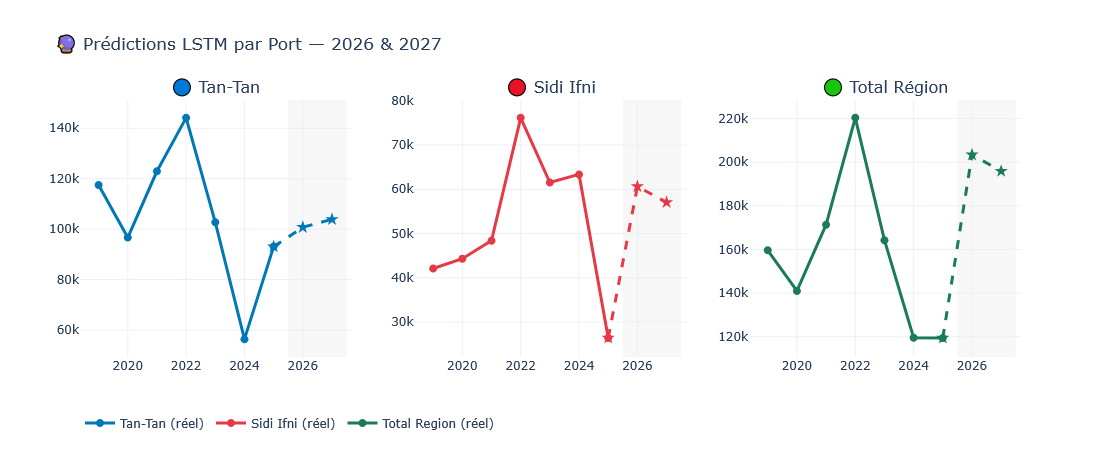


  🔮 RÉCAPITULATIF PRÉDICTIONS LSTM

  Port            2025 (réel)     2026 (prédit)   2027 (prédit)  
  ---------------------------------------------------------
  Tan-Tan         93,063          100,749         103,885        
  Sidi Ifni       26,427          60,624          57,047         
  Total Region    119,490         203,391         195,882        

💾 3 modèles LSTM sauvegardés !


In [3]:
# ═══════════════════════════════════════════
#  CELLULE 3 — VISUALISATION PRÉDICTIONS
# ═══════════════════════════════════════════

import plotly.graph_objects as go
from plotly.subplots import make_subplots

annees_hist = serie['annee'].tolist()
annees_pred = [2026, 2027]

fig = make_subplots(rows=1, cols=3,
    subplot_titles=("🔵 Tan-Tan", "🔴 Sidi Ifni", "🟢 Total Région"))

ports_data = [
    ("Tan-Tan",      serie['tantan_total_t'].tolist(),   pred_tt,  '#0077b6', 1),
    ("Sidi Ifni",    serie['sidiifni_total_t'].tolist(), pred_si,  '#e63946', 2),
    ("Total Region", serie['total_region_t'].tolist(),   pred_reg, '#1a7a5a', 3),
]

for nom, hist, pred, couleur, col in ports_data:
    # Historique
    fig.add_trace(go.Scatter(
        x=annees_hist, y=hist,
        name=f"{nom} (réel)",
        mode='lines+markers',
        line=dict(color=couleur, width=3),
        marker=dict(size=8)
    ), row=1, col=col)

    # Prédictions
    fig.add_trace(go.Scatter(
        x=[annees_hist[-1]] + annees_pred,
        y=[hist[-1]] + list(pred),
        name=f"{nom} (prédit)",
        mode='lines+markers',
        line=dict(color=couleur, width=3, dash='dash'),
        marker=dict(size=10, symbol='star'),
        showlegend=False
    ), row=1, col=col)

    # Zone prédiction
    fig.add_vrect(
        x0=2025.5, x1=2027.5,
        fillcolor='rgba(200,200,200,0.15)',
        layer='below', line_width=0,
        row=1, col=col
    )

fig.update_layout(
    title="🔮 Prédictions LSTM par Port — 2026 & 2027",
    height=450, template='plotly_white',
    legend=dict(orientation='h', y=-0.2)
)
fig.show()

# Tableau récapitulatif
print("\n" + "="*55)
print("  🔮 RÉCAPITULATIF PRÉDICTIONS LSTM")
print("="*55)
print(f"\n  {'Port':<15} {'2025 (réel)':<15} {'2026 (prédit)':<15} {'2027 (prédit)':<15}")
print(f"  {'-'*57}")
print(f"  {'Tan-Tan':<15} {93063:<15,.0f} {pred_tt[0]:<15,.0f} {pred_tt[1]:<15,.0f}")
print(f"  {'Sidi Ifni':<15} {26427:<15,.0f} {pred_si[0]:<15,.0f} {pred_si[1]:<15,.0f}")
print(f"  {'Total Region':<15} {119490:<15,.0f} {pred_reg[0]:<15,.0f} {pred_reg[1]:<15,.0f}")
print("="*55)

# Sauvegarder les modèles
model_tt.save("lstm_tantan.keras")
model_si.save("lstm_sidiifni.keras")
model_reg.save("lstm_region.keras")
print("\n💾 3 modèles LSTM sauvegardés !")